In [1]:
!pip install torch torchvision opencv-python matplotlib pillow scikit-learn

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms

In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia


In [4]:
class CLAHE(object):

    def __init__(self, clip_limit=2.0, tile_grid_size=(8,8)):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size

    def __call__(self, img):

        img = np.array(img)

        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

        clahe = cv2.createCLAHE(
            clipLimit=self.clip_limit,
            tileGridSize=self.tile_grid_size
        )

        img = clahe.apply(img)

        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        return Image.fromarray(img)

In [5]:
train_transform = transforms.Compose([

    CLAHE(),

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [6]:
val_transform = transforms.Compose([

    CLAHE(),

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [7]:
train_dataset = ImageFolder(
    "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train",
    transform=train_transform
)

val_dataset = ImageFolder(
    "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/val",
    transform=val_transform
)

test_dataset = ImageFolder(
    "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test",
    transform=val_transform
)

In [8]:
print(train_dataset.classes)
print(train_dataset.class_to_idx)

['NORMAL', 'PNEUMONIA']
{'NORMAL': 0, 'PNEUMONIA': 1}


In [9]:
batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4
)

In [10]:
def imshow(img):

    img = img.numpy().transpose((1,2,0))

    mean = np.array([0.485,0.456,0.406])
    std = np.array([0.229,0.224,0.225])

    img = std * img + mean
    img = np.clip(img,0,1)

    plt.imshow(img)

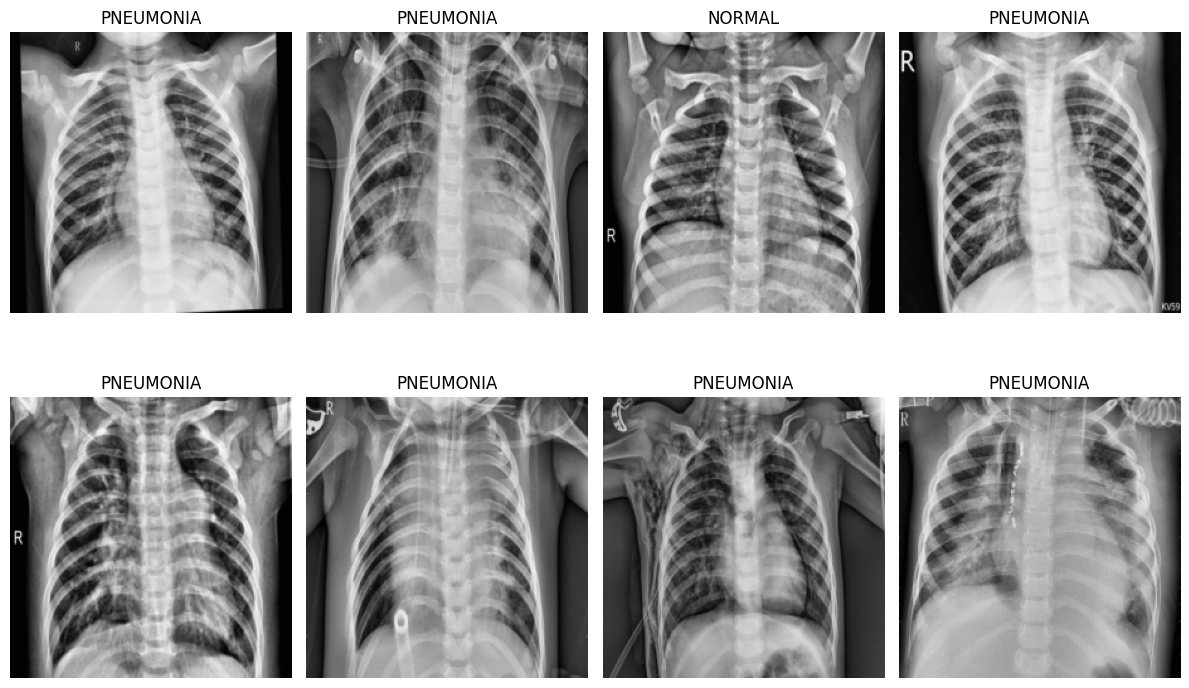

In [11]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12,8))

for i in range(8):

    plt.subplot(2,4,i+1)

    imshow(images[i])

    plt.title(train_dataset.classes[labels[i]])

    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([16, 3, 224, 224])
torch.Size([16])


In [13]:
from torch.utils.data import WeightedRandomSampler
from collections import Counter
import numpy as np

In [14]:
train_labels = [label for _, label in train_dataset.samples]

print(Counter(train_labels))

Counter({1: 3875, 0: 1341})


In [20]:
class_counts = np.bincount(train_labels)

class_weights = 1.0 / class_counts

sample_weights = class_weights[train_labels]

In [21]:
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [22]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    sampler=sampler,
    num_workers=4,
    pin_memory=True
)

In [23]:
images, labels = next(iter(train_loader))

print(labels)

tensor([1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1])


In [24]:
import torch
import torch.nn as nn

from torchvision.models import vit_b_16, ViT_B_16_Weights

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [26]:
weights = ViT_B_16_Weights.DEFAULT

model = vit_b_16(weights=weights)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 237MB/s] 


In [27]:
print(model)

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [28]:
num_classes = len(train_dataset.classes)

print(num_classes)

2


In [29]:
in_features = model.heads.head.in_features

model.heads.head = nn.Linear(
    in_features,
    num_classes
)

In [30]:
print(model)

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [31]:
model = model.to(device)

In [32]:
for param in model.parameters():
    param.requires_grad = False

for param in model.heads.parameters():
    param.requires_grad = True

In [33]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"Trainable Parameters: {trainable:,}")
print(f"Total Parameters: {total:,}")

Trainable Parameters: 1,538
Total Parameters: 85,800,194


In [34]:
criterion = nn.CrossEntropyLoss()

In [35]:
optimizer = torch.optim.AdamW(
    model.heads.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [36]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=3
)

In [37]:
images, labels = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print(outputs.shape)

torch.Size([16, 2])


In [38]:
torch.Size([batch_size, num_classes])

torch.Size([16, 2])

In [39]:
from tqdm import tqdm
import copy

In [40]:
scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_58/2340218076.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [41]:
num_epochs = 30

best_val_loss = float("inf")
best_model = None

patience = 5
counter = 0

In [42]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

In [43]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress = tqdm(loader)

    for images, labels in progress:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

        progress.set_description(
            f"Loss: {loss.item():.4f}"
        )

    epoch_loss = running_loss / len(loader)

    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [44]:
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0

    correct = 0

    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)

    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [45]:
for epoch in range(num_epochs):

    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        scaler,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.2f}%")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.2f}%")

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_model = copy.deepcopy(model.state_dict())

        torch.save(best_model, "best_vit_model.pth")

        print("Best model saved.")

        counter = 0

    else:

        counter += 1

        print(f"EarlyStopping Counter : {counter}")

        if counter >= patience:

            print("Early stopping.")

            break


Epoch 1/30


  0%|          | 0/326 [00:00<?, ?it/s]/tmp/ipykernel_58/1024700552.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Loss: 0.2482: 100%|██████████| 326/326 [01:37<00:00,  3.34it/s]


Train Loss : 0.3715
Train Acc  : 87.75%
Val Loss   : 0.3252
Val Acc    : 87.50%
Best model saved.

Epoch 2/30


Loss: 0.0729: 100%|██████████| 326/326 [01:35<00:00,  3.40it/s]


Train Loss : 0.2227
Train Acc  : 92.48%
Val Loss   : 0.2605
Val Acc    : 93.75%
Best model saved.

Epoch 3/30


...

Train Loss : 0.0751
Train Acc  : 97.53%
Val Loss   : 0.1688
Val Acc    : 93.75%
EarlyStopping Counter : 2

Epoch 29/30


Loss: 0.0327: 100%|██████████| 326/326 [01:33<00:00,  3.48it/s]


Train Loss : 0.0718
Train Acc  : 97.68%
Val Loss   : 0.1738
Val Acc    : 93.75%
EarlyStopping Counter : 3

Epoch 30/30


Loss: 0.0437: 100%|██████████| 326/326 [01:33<00:00,  3.49it/s]


Train Loss : 0.0709
Train Acc  : 97.70%
Val Loss   : 0.1449
Val Acc    : 93.75%
EarlyStopping Counter : 4


In [46]:
model.load_state_dict(
    torch.load(
        "best_vit_model.pth",
        map_location=device
    )
)

<All keys matched successfully>

In [47]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

import torch.nn.functional as F

In [48]:
model.eval()

test_loss = 0

all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item()

        probabilities = F.softmax(outputs, dim=1)

        _, predictions = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())

        all_predictions.extend(predictions.cpu().numpy())

        all_probabilities.extend(probabilities.cpu().numpy())

In [49]:
all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)

test_loss /= len(test_loader)

In [50]:
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {accuracy:.4f}")

Test Loss     : 0.3980
Test Accuracy : 0.8574


In [51]:
precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted"
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted"
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted"
)

print("Precision :", precision)
print("Recall    :", recall)
print("F1 Score  :", f1)

Precision : 0.8720252069275451
Recall    : 0.8573717948717948
F1 Score  : 0.8502953091842641


In [52]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_dataset.classes
    )
)

              precision    recall  f1-score   support

      NORMAL       0.95      0.65      0.77       234
   PNEUMONIA       0.83      0.98      0.90       390

    accuracy                           0.86       624
   macro avg       0.89      0.82      0.84       624
weighted avg       0.87      0.86      0.85       624



<Figure size 800x800 with 0 Axes>

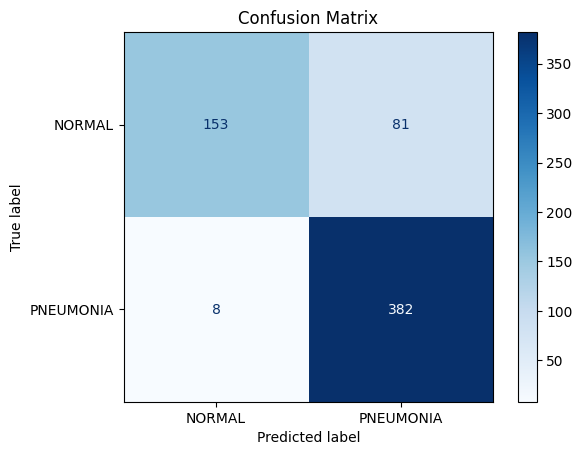

In [53]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes
)

plt.figure(figsize=(8,8))

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")

plt.show()

In [54]:
classes = np.arange(len(test_dataset.classes))

labels_bin = label_binarize(
    all_labels,
    classes=classes
)

In [56]:
from sklearn.metrics import roc_auc_score, roc_curve

# True labels (shape: [N])
y_true = all_labels

# Probability of the positive class (shape: [N])
y_score = all_probabilities[:, 1]

roc_auc = roc_auc_score(y_true, y_score)

print("ROC AUC:", roc_auc)

ROC AUC: 0.9570567609029148


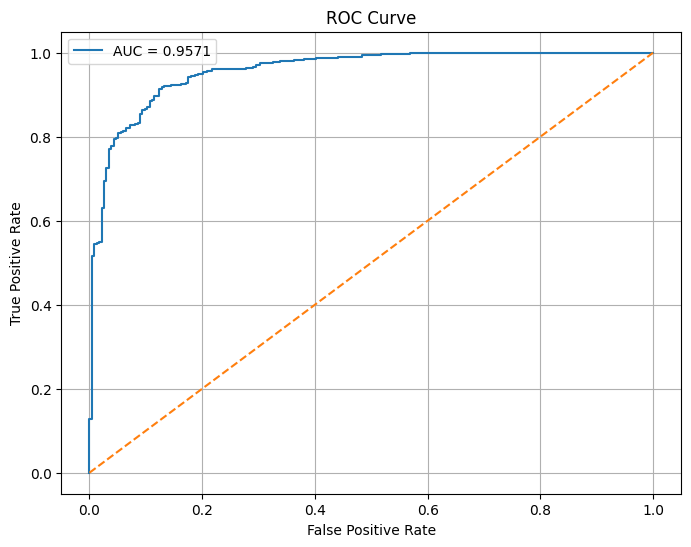

In [62]:
fpr, tpr, thresholds = roc_curve(y_true, y_score)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

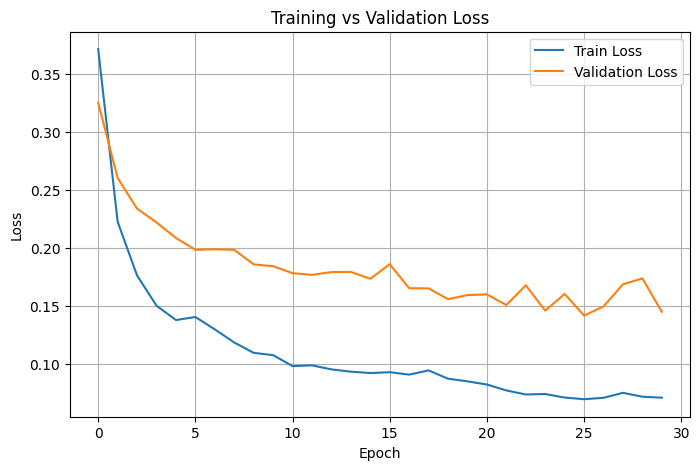

In [63]:
plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

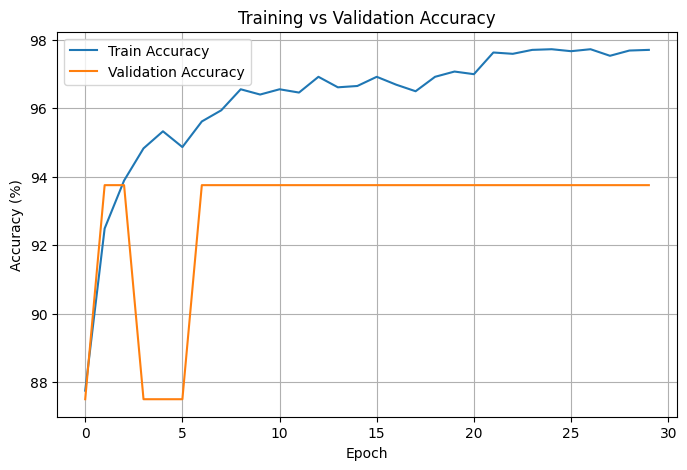

In [64]:
plt.figure(figsize=(8,5))

plt.plot(
    train_accuracies,
    label="Train Accuracy"
)

plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()